https://m.sports.naver.com/wfootball/article/109/0005598416

해당 파일 내용을 복붙해서 article.txt로 저장


In [5]:
import requests

url = "https://raw.githubusercontent.com/park1200656/KnuSentiLex/master/SentiWord_Dict.txt"
response = requests.get(url)
response.encoding = 'utf-8'

with open("data/SentiWord_Dict.txt", "w", encoding="utf-8") as f:
    f.write(response.text)

print("감성사전 다운로드 완료")

감성사전 다운로드 완료


감성사전 단어 개수: 14851

=== 긍정 단어 TOP 10 ===
득점: 2.0 (등장 1회)
사랑: 2.0 (등장 2회)
최고: 2.0 (등장 1회)
개성: 1.0 (등장 1회)
도움: 1.0 (등장 1회)
전문가: 1.0 (등장 2회)
정상: 1.0 (등장 2회)

=== 부정 단어 TOP 10 ===
모욕: -2.0 (등장 1회)
절망: -2.0 (등장 1회)
좌절: -2.0 (등장 1회)
눈물: -1.0 (등장 2회)
비판: -1.0 (등장 3회)

기사 전체 감성 점수 합계: 3.00


C:\Users\playdata2\AppData\Local\Temp\ipykernel_1788\3272989381.py:79: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.savefig("data/wordcloud_sentiment.png", bbox_inches='tight')
C:\Users\playdata2\AppData\Local\Temp\ipykernel_1788\3272989381.py:79: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.savefig("data/wordcloud_sentiment.png", bbox_inches='tight')
C:\Users\playdata2\AppData\Local\Temp\ipykernel_1788\3272989381.py:79: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) DejaVu Sans.
  plt.savefig("data/wordcloud_sentiment.png", bbox_inches='tight')
C:\Users\playdata2\AppData\Local\Temp\ipykernel_1788\3272989381.py:79: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.savefig("data/wordcloud_sentiment.png", bbox_inches='tight')
C:\Users\playdata2\AppData\Local\Temp\ipykernel_1788\3272989381.py:79: UserWarning: Glyph 53364 (\N{HANGUL SYL

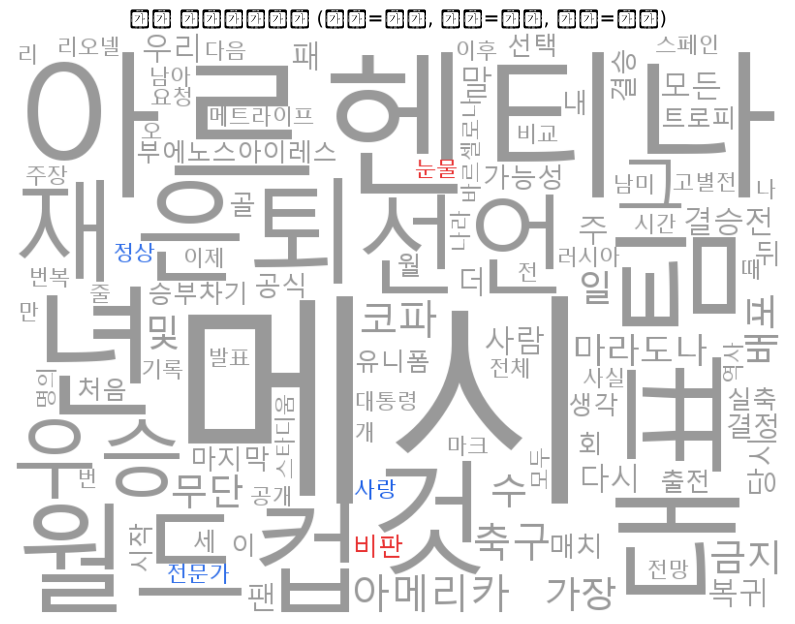

감성 워드클라우드 저장 완료: data/wordcloud_sentiment.png


In [7]:
import pandas as pd

# ==========================================
# 8. 감성사전 불러오기
# ==========================================
# KNU 감성사전: 단어 \t 점수 형태의 텍스트 파일
sentiment_dict = {}
with open("data/SentiWord_Dict.txt", "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 2:
            word, score = parts
            try:
                sentiment_dict[word] = float(score)
            except ValueError:
                continue

print("감성사전 단어 개수:", len(sentiment_dict))

# ==========================================
# 9. 추출된 단어별 감성 점수 매칭
# ==========================================
word_sentiment = {}
for word, freq in word_counts.items():
    score = sentiment_dict.get(word, 0)  # 사전에 없으면 중립(0)으로 처리
    word_sentiment[word] = score

# 빈도 * 감성점수를 곱해서, "많이 등장하면서 감성이 강한 단어"를 강조
# (단순 빈도만으로는 감성 정보가 안 보이니, 가중치를 결합)
word_weighted = {
    word: freq * (1 + abs(word_sentiment[word]))  # 감성이 강할수록 크게 표시
    for word, freq in word_counts.items()
}

# ==========================================
# 10. 긍정/부정 상위 단어 확인
# ==========================================
positive_words = {w: s for w, s in word_sentiment.items() if s > 0}
negative_words = {w: s for w, s in word_sentiment.items() if s < 0}

print("\n=== 긍정 단어 TOP 10 ===")
for word, score in sorted(positive_words.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{word}: {score} (등장 {word_counts[word]}회)")

print("\n=== 부정 단어 TOP 10 ===")
for word, score in sorted(negative_words.items(), key=lambda x: x[1])[:10]:
    print(f"{word}: {score} (등장 {word_counts[word]}회)")

# 전체 기사의 감성 총점 (긍정 단어 점수 - 부정 단어 점수, 빈도 가중)
total_sentiment = sum(word_sentiment[w] * freq for w, freq in word_counts.items())
print(f"\n기사 전체 감성 점수 합계: {total_sentiment:.2f}")

# ==========================================
# 11. 감성에 따라 색상이 다른 워드클라우드
#     - 긍정: 파란색 계열, 부정: 빨간색 계열, 중립: 회색 계열
# ==========================================
def sentiment_color_func(word, **kwargs):
    score = word_sentiment.get(word, 0)
    if score > 0:
        return "hsl(220, 80%%, %d%%)" % max(30, 60 - int(score * 5))   # 파랑(긍정)
    elif score < 0:
        return "hsl(0, 80%%, %d%%)" % max(30, 60 - int(abs(score) * 5))  # 빨강(부정)
    else:
        return "hsl(0, 0%, 60%)"  # 회색(중립)

wc = WordCloud(
    font_path='malgun.ttf',
    background_color='white',
    width=800,
    height=600,
    max_words=100,
    color_func=sentiment_color_func
).generate_from_frequencies(word_counts)

plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("기사 워드클라우드 (파랑=긍정, 빨강=부정, 회색=중립)", fontsize=14)
plt.savefig("data/wordcloud_sentiment.png", bbox_inches='tight')
plt.show()

print("감성 워드클라우드 저장 완료: data/wordcloud_sentiment.png")